<a href="https://colab.research.google.com/github/LuanCarrieiros/IA/blob/main/Lista12/lista12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Monta o Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Configura a API do Kaggle (copiando do seu Drive)
!mkdir -p ~/.kaggle
!cp "/content/drive/MyDrive/Colab Notebooks/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("API do Kaggle configurada.")

Mounted at /content/drive
API do Kaggle configurada.


In [7]:
# Baixa os arquivos da competição "dogs-vs-cats" do Kaggle
# Baixa os arquivos da competição
!kaggle competitions download -c dogs-vs-cats

# Cria a pasta e descompacta os arquivos nela
!mkdir -p ./data
!unzip -q dogs-vs-cats.zip -d ./data/
!unzip -q ./data/train.zip -d ./data/
!unzip -q ./data/test1.zip -d ./data/
print("Dados baixados e descompactados.")

100% 812M/812M [00:05<00:00, 246MB/s]
100% 812M/812M [00:05<00:00, 154MB/s]
Dados baixados e descompactados.


In [8]:
import os
import shutil
from sklearn.model_selection import train_test_split
import numpy as np

# --- 1. Limpar diretórios antigos (se existirem) para evitar misturar dados ---
base_dir = './data'
if os.path.exists(os.path.join(base_dir, 'train_split')):
    shutil.rmtree(os.path.join(base_dir, 'train_split'))
if os.path.exists(os.path.join(base_dir, 'validation_split')):
    shutil.rmtree(os.path.join(base_dir, 'validation_split'))
print("Diretórios antigos removidos.")

# --- 2. Definir todos os caminhos necessários ---
original_data_dir = os.path.join(base_dir, 'train')

train_dir = os.path.join(base_dir, 'train_set')
validation_dir = os.path.join(base_dir, 'validation_set')
test_dir = os.path.join(base_dir, 'test_set')

# --- 3. Criar a nova estrutura de pastas 70/15/15 ---
# Formato: data/{train_set, validation_set, test_set}/{cats, dogs}
for dir_path in [train_dir, validation_dir, test_dir]:
    os.makedirs(os.path.join(dir_path, 'cats'), exist_ok=True)
    os.makedirs(os.path.join(dir_path, 'dogs'), exist_ok=True)
print("Nova estrutura de diretórios 70/15/15 criada.")

# --- 4. Separar os nomes dos arquivos por classe ---
all_filenames = os.listdir(original_data_dir)
cat_filenames = [fname for fname in all_filenames if fname.startswith('cat')]
dog_filenames = [fname for fname in all_filenames if fname.startswith('dog')]

# --- 5. Fazer a divisão 70/15/15 para cada classe ---
# Dividindo gatos
train_cats, temp_cats = train_test_split(cat_filenames, test_size=0.30, random_state=42)
validation_cats, test_cats = train_test_split(temp_cats, test_size=0.50, random_state=42) # 0.50 de 30% = 15%

# Dividindo cães
train_dogs, temp_dogs = train_test_split(dog_filenames, test_size=0.30, random_state=42)
validation_dogs, test_dogs = train_test_split(temp_dogs, test_size=0.50, random_state=42) # 0.50 de 30% = 15%

# --- 6. Função para copiar os arquivos ---
def copy_files(filenames, source_dir, dest_dir):
    for filename in filenames:
        src = os.path.join(source_dir, filename)
        dst = os.path.join(dest_dir, filename)
        shutil.copyfile(src, dst)

# --- 7. Copiar os arquivos para seus respectivos diretórios ---
print("Copiando arquivos...")
# Copiando arquivos de treino
copy_files(train_cats, original_data_dir, os.path.join(train_dir, 'cats'))
copy_files(train_dogs, original_data_dir, os.path.join(train_dir, 'dogs'))

# Copiando arquivos de validação
copy_files(validation_cats, original_data_dir, os.path.join(validation_dir, 'cats'))
copy_files(validation_dogs, original_data_dir, os.path.join(validation_dir, 'dogs'))

# Copiando arquivos de teste
copy_files(test_cats, original_data_dir, os.path.join(test_dir, 'cats'))
copy_files(test_dogs, original_data_dir, os.path.join(test_dir, 'dogs'))

# --- 8. Verificação final ---
print("\n--- Organização 70/15/15 Concluída ---")
print(f"Imagens de treino (gatos): {len(os.listdir(os.path.join(train_dir, 'cats')))}")
print(f"Imagens de treino (cães): {len(os.listdir(os.path.join(train_dir, 'dogs')))}")
print(f"Total de treino: {len(os.listdir(os.path.join(train_dir, 'cats'))) + len(os.listdir(os.path.join(train_dir, 'dogs')))}\n")

print(f"Imagens de validação (gatos): {len(os.listdir(os.path.join(validation_dir, 'cats')))}")
print(f"Imagens de validação (cães): {len(os.listdir(os.path.join(validation_dir, 'dogs')))}")
print(f"Total de validação: {len(os.listdir(os.path.join(validation_dir, 'cats'))) + len(os.listdir(os.path.join(validation_dir, 'dogs')))}\n")

print(f"Imagens de teste (gatos): {len(os.listdir(os.path.join(test_dir, 'cats')))}")
print(f"Imagens de teste (cães): {len(os.listdir(os.path.join(test_dir, 'dogs')))}")
print(f"Total de teste: {len(os.listdir(os.path.join(test_dir, 'cats'))) + len(os.listdir(os.path.join(test_dir, 'dogs')))}")

Diretórios antigos removidos.
Nova estrutura de diretórios 70/15/15 criada.
Copiando arquivos...

--- Organização 70/15/15 Concluída ---
Imagens de treino (gatos): 8750
Imagens de treino (cães): 8750
Total de treino: 17500

Imagens de validação (gatos): 1875
Imagens de validação (cães): 1875
Total de validação: 3750

Imagens de teste (gatos): 1875
Imagens de teste (cães): 1875
Total de teste: 3750


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. Definir os caminhos para os novos diretórios ---
train_dir = './data/train_set'
validation_dir = './data/validation_set'
# O diretório de teste ('./data/test_set') será usado apenas no final.

# --- 2. Criar o ImageDataGenerator para o conjunto de TREINO (com Data Augmentation) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# --- 3. Criar o ImageDataGenerator para o conjunto de VALIDAÇÃO (apenas normalização) ---
validation_datagen = ImageDataGenerator(rescale=1./255)

# --- 4. Criar os geradores que alimentarão o modelo ---
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

print("\nPré-processamento e geradores de dados configurados com sucesso!")

Found 17500 images belonging to 2 classes.
Found 3750 images belonging to 2 classes.

Pré-processamento e geradores de dados configurados com sucesso!


In [10]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    # Bloco Convolucional 1
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Bloco Convolucional 2
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Bloco Convolucional 3
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Preparação para a parte de classificação
    tf.keras.layers.Flatten(),

    # Camada Densa de classificação
    tf.keras.layers.Dense(512, activation='relu'),

    # Camada de Saída
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Definindo o número de épocas
EPOCHS = 15

# O treinamento propriamente dito!
history = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      verbose=1
)

print("Treinamento concluído!")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 133s 230ms/step - accuracy: 0.5416 - loss: 0.7230 - val_accuracy: 0.6264 - val_loss: 0.6428
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 132s 221ms/step - accuracy: 0.6404 - loss: 0.6319 - val_accuracy: 0.7115 - val_loss: 0.5646
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 121s 221ms/step - accuracy: 0.6800 - loss: 0.5938 - val_accuracy: 0.7176 - val_loss: 0.5567
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 143s 222ms/step - accuracy: 0.7148 - loss: 0.5576 - val_accuracy: 0.7512 - val_loss: 0.5108
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 125s 229ms/step - accuracy: 0.7343 - loss: 0.5343 - val_accuracy: 0.7667 - val_loss: 0.4856
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 121s 221ms/step - accuracy: 0.7368 - loss: 0.5235 - val_accuracy: 0.7987 - val_loss: 0.4467
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 122s 224ms/step - accuracy: 0.7623 - loss: 0.4902 - val_accuracy: 0.7915 - val_loss: 0.4684
Epoch 8/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 122s 223ms/step - accuracy: 0.7660 -

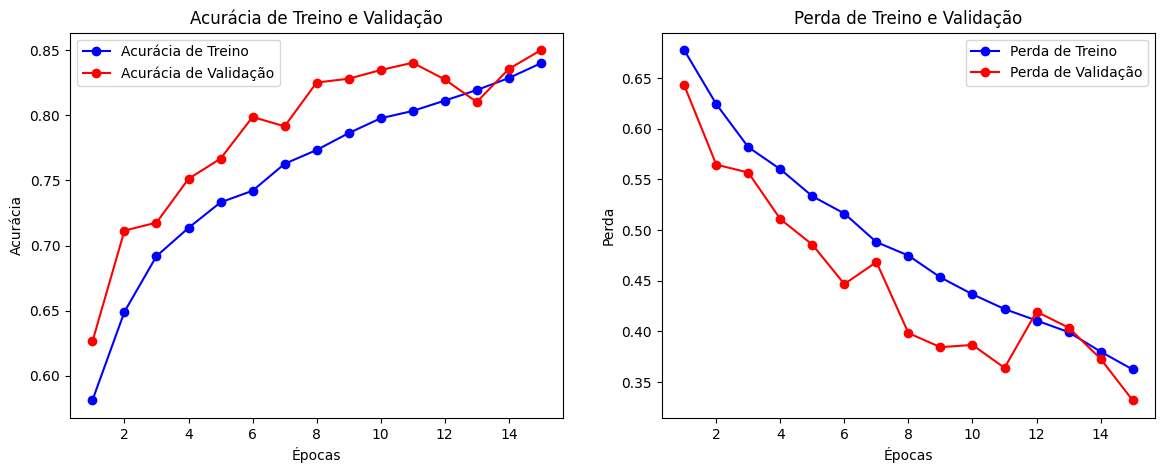

In [13]:
import matplotlib.pyplot as plt

# Extrair os dados do objeto 'history'
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Criar o gráfico de Acurácia
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Acurácia de Treino')
plt.plot(epochs, val_acc, 'ro-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

# Criar o gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Perda de Treino')
plt.plot(epochs, val_loss, 'ro-', label='Perda de Validação')
plt.title('Perda de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()

plt.show()

Found 3750 images belonging to 2 classes.

Fazendo predições no conjunto de teste...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

        cats       0.89      0.82      0.86      1875
        dogs       0.84      0.90      0.87      1875

    accuracy                           0.86      3750
   macro avg       0.87      0.86      0.86      3750
weighted avg       0.87      0.86      0.86      3750


--- Matriz de Confusão ---


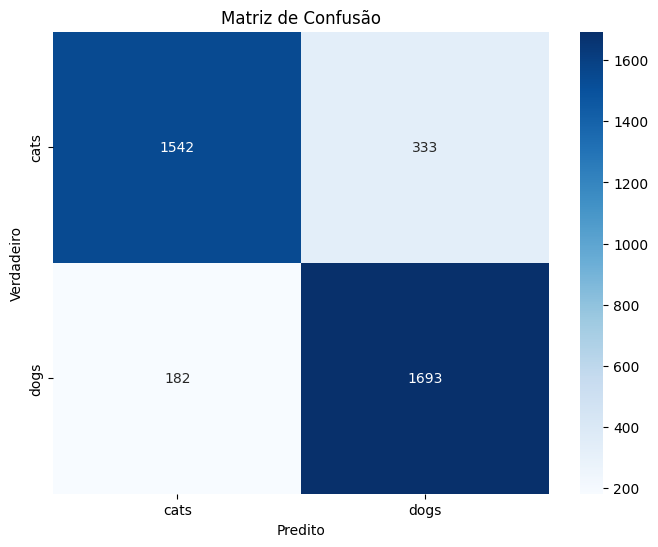

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Criar um gerador APENAS para os dados de teste
# NUNCA aplicamos aumento de dados (augmentation) no conjunto de teste.
# 'shuffle=False' é MUITO importante para garantir que a ordem das predições corresponda à ordem dos rótulos reais.
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    './data/test_set',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# 2. Fazer as predições no conjunto de teste
print("\nFazendo predições no conjunto de teste...")
predictions = model.predict(test_generator)

# Converter as probabilidades (saídas da sigmoid) em classes (0 ou 1)
# Se a predição for > 0.5, classificamos como 1 (cão), senão como 0 (gato)
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)

# 3. Obter os rótulos verdadeiros
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 4. Calcular e exibir o Relatório de Classificação
print("\n--- Relatório de Classificação ---")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# 5. Calcular e exibir a Matriz de Confusão
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

Por favor, faça o upload de uma imagem de gato ou cachorro:


Saving 2.jpg to 2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step

Analisando a imagem: 2.jpg
Predição: É um Cachorro! 🐶


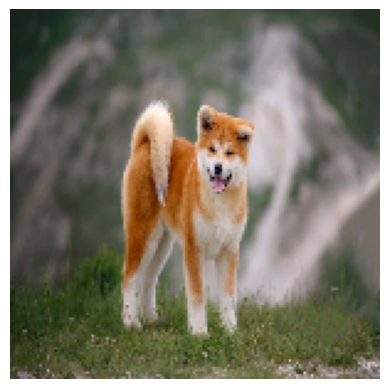

In [15]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Abre a caixa de diálogo para você escolher e fazer o upload da imagem
print("Por favor, faça o upload de uma imagem de gato ou cachorro:")
uploaded = files.upload()

# Pega o nome do arquivo que você acabou de subir
for fn in uploaded.keys():
  path = fn

  # 2. Carregar a imagem e aplicar o mesmo pré-processamento do treino
  img = image.load_img(path, target_size=(150, 150))
  img_array = image.img_to_array(img)
  img_batch = np.expand_dims(img_array, axis=0)
  img_preprocessed = img_batch / 255.

  # 3. Fazer a predição
  prediction = model.predict(img_preprocessed)

  # 4. Exibir a imagem e o resultado
  plt.imshow(img)
  plt.axis('off')

  print(f"\nAnalisando a imagem: {fn}")
  if prediction[0][0] > 0.5:
      print("Predição: É um Cachorro! 🐶")
  else:
      print("Predição: É um Gato! 🐱")

Por favor, faça o upload de uma imagem de gato ou cachorro:


Saving 1.jpg to 1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Analisando a imagem: 1.jpg
Predição: É um Gato! 🐱


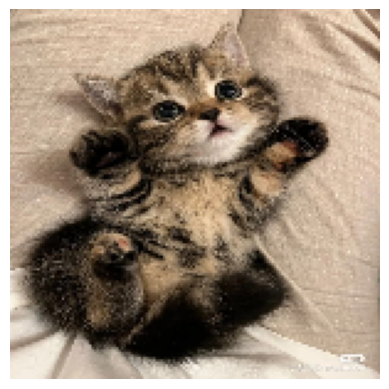

In [16]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Abre a caixa de diálogo para você escolher e fazer o upload da imagem
print("Por favor, faça o upload de uma imagem de gato ou cachorro:")
uploaded = files.upload()

# Pega o nome do arquivo que você acabou de subir
for fn in uploaded.keys():
  path = fn

  # 2. Carregar a imagem e aplicar o mesmo pré-processamento do treino
  img = image.load_img(path, target_size=(150, 150))
  img_array = image.img_to_array(img)
  img_batch = np.expand_dims(img_array, axis=0)
  img_preprocessed = img_batch / 255.

  # 3. Fazer a predição
  prediction = model.predict(img_preprocessed)

  # 4. Exibir a imagem e o resultado
  plt.imshow(img)
  plt.axis('off')

  print(f"\nAnalisando a imagem: {fn}")
  if prediction[0][0] > 0.5:
      print("Predição: É um Cachorro! 🐶")
  else:
      print("Predição: É um Gato! 🐱")